In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, recall_score, precision_score, 
                           f1_score, accuracy_score, roc_curve, roc_auc_score, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


In [ ]:
# Data Loading and Preprocessing Functions

def load_and_preprocess_data(parquet_path):
    """Load and preprocess the conflict data"""
    df = pd.read_parquet(parquet_path)
    df = df.dropna()
    df['target'] = (df['conflict_count'] >= 1).astype(int)
    
    # Create features
    features = df.drop(['GEOID', 'conflict_count', 'target'], axis=1)
    features = pd.get_dummies(features, columns=['year'], prefix='year')
    
    X = features
    y = df['target']
    
    print(f"Dataset shape: {X.shape}")
    print(f"Class distribution: {y.value_counts().to_dict()}")
    
    return X, y

def prepare_data_splits(X, y, test_size=0.2, random_state=42):
    """Prepare train-test splits with scaling and SMOTE"""
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # SMOTE for training data
    smote = SMOTE(random_state=random_state)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    
    return {
        'X_train_scaled': X_train_scaled,
        'X_test_scaled': X_test_scaled, 
        'X_train_smote': X_train_smote,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_smote': y_train_smote,
        'scaler': scaler
    }

import sys
from pathlib import Path
_root = Path.cwd().resolve()
for _ in range(16):
    if (_root / "pyproject.toml").exists():
        break
    _root = _root.parent
else:
    raise FileNotFoundError("Run this notebook from inside the project repository.")
sys.path.insert(0, str(_root / "src"))
from conflict_project.repo_paths import training_parquet_path

# Load data
parquet_path = training_parquet_path()
X, y = load_and_preprocess_data(parquet_path)
data_splits = prepare_data_splits(X, y)


Dataset shape: (34015, 15)
Class distribution: {0: 31256, 1: 2759}
Data preprocessing completed!


In [ ]:
# Individual Model Functions

class ConflictPredictor(nn.Module):
    """Simple Neural Network for Conflict Prediction"""
    def __init__(self, input_size):
        super(ConflictPredictor, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

def train_logistic_regression(X_train, y_train, X_test, y_test):
    """Train and evaluate Logistic Regression"""
    # Hyperparameter grid
    param_grid = {
        'C': np.logspace(-3, 1, 5),
        'l1_ratio': np.linspace(0, 1, 5)
    }
    
    # Model
    model = LogisticRegression(
        solver='saga', penalty='elasticnet', 
        max_iter=1000, random_state=42
    )
    
    # Grid search
    grid = GridSearchCV(model, param_grid, scoring='recall_weighted', cv=5, n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Predictions
    y_pred = grid.best_estimator_.predict(X_test)
    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    return {
        'model': grid.best_estimator_,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'best_params': grid.best_params_,
        'name': 'Logistic Regression'
    }

def train_knn(X_train, y_train, X_test, y_test):
    """Train and evaluate K-Nearest Neighbors"""
    param_grid = [
        {
            'knn__n_neighbors': [3, 5, 7],
            'knn__weights': ['uniform', 'distance'],
            'knn__metric': ['euclidean']
        },
        {
            'knn__n_neighbors': [3, 5, 7],
            'knn__weights': ['uniform', 'distance'],
            'knn__metric': ['cosine']
        }
    ]
    
    # Pipeline with scaling and SMOTE
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('knn', KNeighborsClassifier(algorithm='brute'))
    ])
    
    # Grid search
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Predictions
    y_pred = grid.best_estimator_.predict(X_test)
    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    return {
        'model': grid.best_estimator_,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'best_params': grid.best_params_,
        'name': 'K-Nearest Neighbors'
    }

def train_random_forest(X_train, y_train, X_test, y_test):
    """Train and evaluate Random Forest"""
    param_grid = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced', None]
    }
    
    model = RandomForestClassifier(random_state=42)
    
    # Randomized search for efficiency
    grid = RandomizedSearchCV(
        model, param_grid, n_iter=50, cv=5, 
        scoring='recall', n_jobs=-1, random_state=42
    )
    grid.fit(X_train, y_train)
    
    # Predictions
    y_pred = grid.best_estimator_.predict(X_test)
    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    return {
        'model': grid.best_estimator_,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'best_params': grid.best_params_,
        'name': 'Random Forest'
    }

def train_neural_network(X_train, y_train, X_test, y_test):
    """Train and evaluate Neural Network"""
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train.values.reshape(-1, 1))
    X_test_tensor = torch.FloatTensor(X_test)
    
    # Model setup
    input_size = X_train.shape[1]
    model = ConflictPredictor(input_size)
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    
    # Training
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    
    model.train()
    for epoch in range(100):
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
    
    # Predictions
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        y_prob = test_outputs.numpy().flatten()
        y_pred = (y_prob > 0.5).astype(int)
    
    return {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'best_params': {'epochs': 100, 'lr': 0.01},
        'name': 'Neural Network'
    }


Model functions defined successfully!


In [ ]:
# Evaluation Functions

def calculate_metrics(y_true, y_pred, y_prob=None):
    """Calculate comprehensive evaluation metrics"""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'weighted_recall': recall_score(y_true, y_pred, average='weighted')
    }
    
    if y_prob is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
    
    return metrics

def create_comparison_table(results_dict):
    """Create comparison table for all models"""
    comparison_data = []
    
    for model_name, result in results_dict.items():
        metrics = calculate_metrics(
            data_splits['y_test'], 
            result['y_pred'], 
            result['y_prob']
        )
        metrics['model'] = model_name
        comparison_data.append(metrics)
    
    df = pd.DataFrame(comparison_data)
    df = df.set_index('model')
    return df.round(4)

def plot_confusion_matrices(results_dict, figsize=(15, 10)):
    """Plot confusion matrices for all models"""
    n_models = len(results_dict)
    
    # Calculate grid dimensions dynamically
    n_cols = 3  # 3 columns for better layout with 6 models
    n_rows = (n_models + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle different grid sizes
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    axes = axes.ravel()
    
    for idx, (name, result) in enumerate(results_dict.items()):
        if idx >= len(axes):
            break
            
        cm = confusion_matrix(data_splits['y_test'], result['y_pred'])
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                   xticklabels=['No Conflict', 'Conflict'],
                   yticklabels=['No Conflict', 'Conflict'])
        axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(data_splits["y_test"], result["y_pred"]):.3f}')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    # Hide unused subplots
    for idx in range(len(results_dict), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


Evaluation functions defined successfully!


In [ ]:
# Train All Individual Models

print("Training individual models...")

# Train all models
individual_results = {}

print("1. Training Logistic Regression...")
individual_results['Logistic Regression'] = train_logistic_regression(
    data_splits['X_train_smote'], data_splits['y_train_smote'], 
    data_splits['X_test_scaled'], data_splits['y_test']
)

print("2. Training K-Nearest Neighbors...")
individual_results['K-Nearest Neighbors'] = train_knn(
    data_splits['X_train_scaled'], data_splits['y_train'], 
    data_splits['X_test_scaled'], data_splits['y_test']
)

print("3. Training Random Forest...")
individual_results['Random Forest'] = train_random_forest(
    data_splits['X_train_smote'], data_splits['y_train_smote'], 
    data_splits['X_test_scaled'], data_splits['y_test']
)

print("4. Training Neural Network...")
individual_results['Neural Network'] = train_neural_network(
    data_splits['X_train_smote'], data_splits['y_train_smote'], 
    data_splits['X_test_scaled'], data_splits['y_test']
)

print("All individual models trained successfully!")



Training individual models...
1. Training Logistic Regression...
2. Training K-Nearest Neighbors...
3. Training Random Forest...
4. Training Neural Network...
All individual models trained successfully!


NameError: name 'create_comparison_table' is not defined


=== Individual Model Performance ===
                     accuracy  precision  recall  f1_score  weighted_recall  \
model                                                                         
Logistic Regression    0.8524     0.3240  0.7536    0.4532           0.8524   
K-Nearest Neighbors    0.8911     0.3994  0.6793    0.5030           0.8911   
Random Forest          0.9291     0.5500  0.6975    0.6150           0.9291   
Neural Network         0.8853     0.3944  0.7717    0.5221           0.8853   

                     roc_auc  
model                         
Logistic Regression   0.8801  
K-Nearest Neighbors   0.8383  
Random Forest         0.9369  
Neural Network        0.9217  


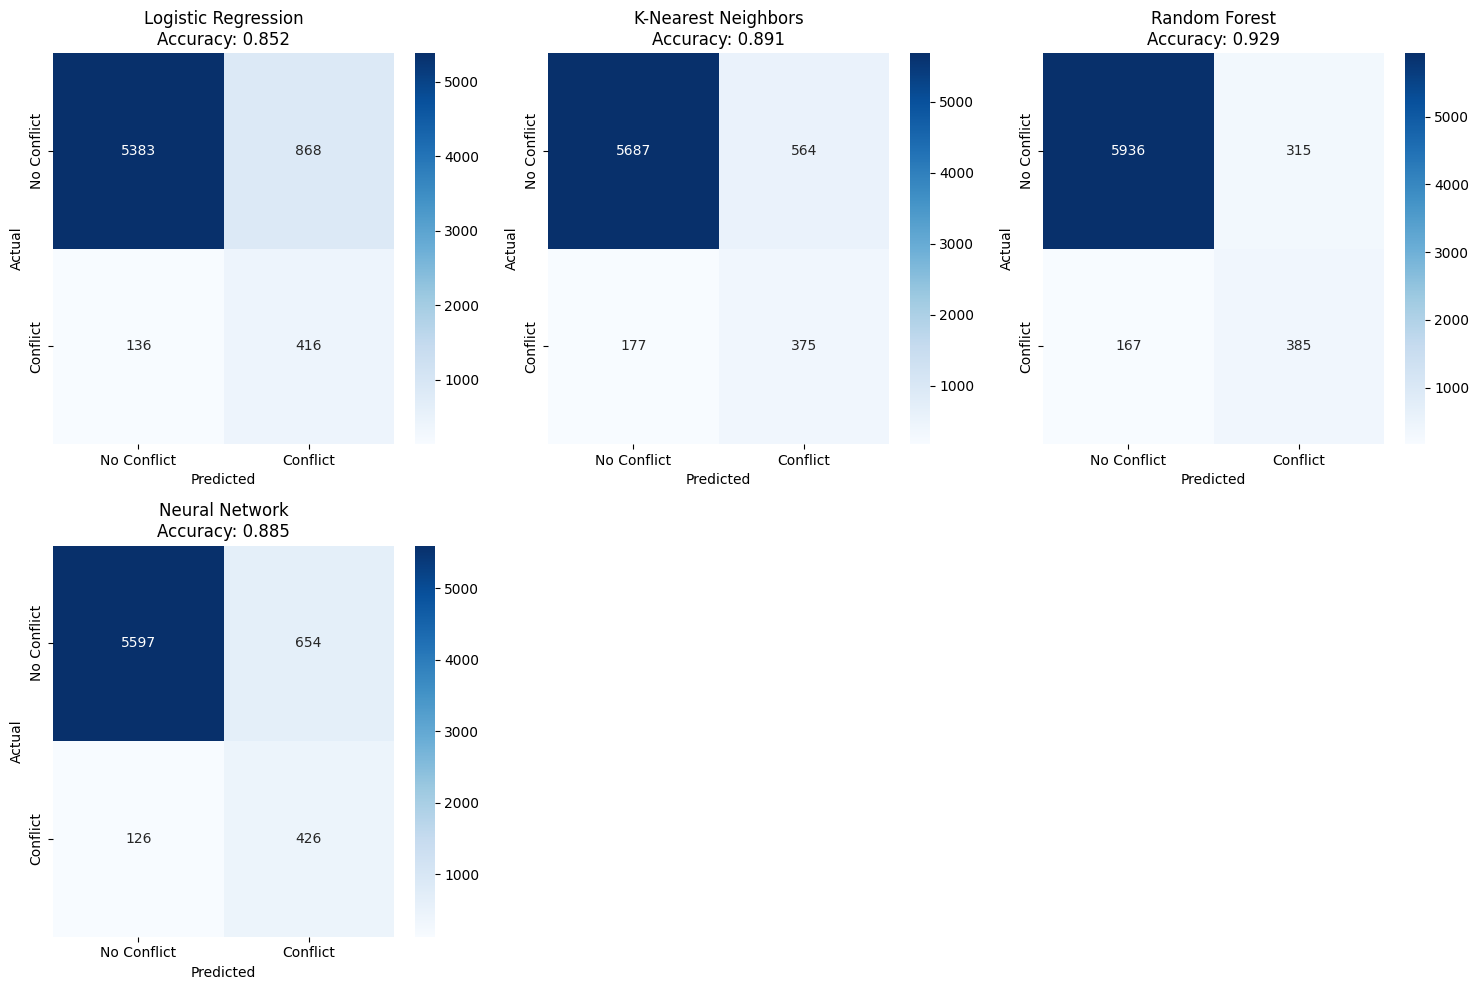

In [9]:
# Create comparison table
comparison_table = create_comparison_table(individual_results)
print("\n=== Individual Model Performance ===")
print(comparison_table)

# Plot confusion matrices
plot_confusion_matrices(individual_results)

Creating weighted ensemble models...

=== Weighted Ensemble Performance ===
               accuracy  precision  recall  f1_score  weighted_recall  roc_auc
model                                                                         
High Recall      0.9083     0.4603  0.7554    0.5720           0.9083   0.9326
RF+NN Focus      0.9167     0.4910  0.7391    0.5900           0.9167   0.9330
Balanced         0.9190     0.5006  0.7337    0.5952           0.9190   0.9329
Equal Weights    0.9172     0.4933  0.7283    0.5881           0.9172   0.9290
Conservative     0.9234     0.5202  0.7228    0.6050           0.9234   0.9294
RF Dominant      0.9272     0.5395  0.7047    0.6112           0.9272   0.9374

=== Ensemble Weights ===

Equal Weights:
  Logistic Regression: 0.25
  K-Nearest Neighbors: 0.25
  Random Forest: 0.25
  Neural Network: 0.25

RF+NN Focus:
  Logistic Regression: 0.15
  K-Nearest Neighbors: 0.15
  Random Forest: 0.35
  Neural Network: 0.35

High Recall:
  Logistic Regressio

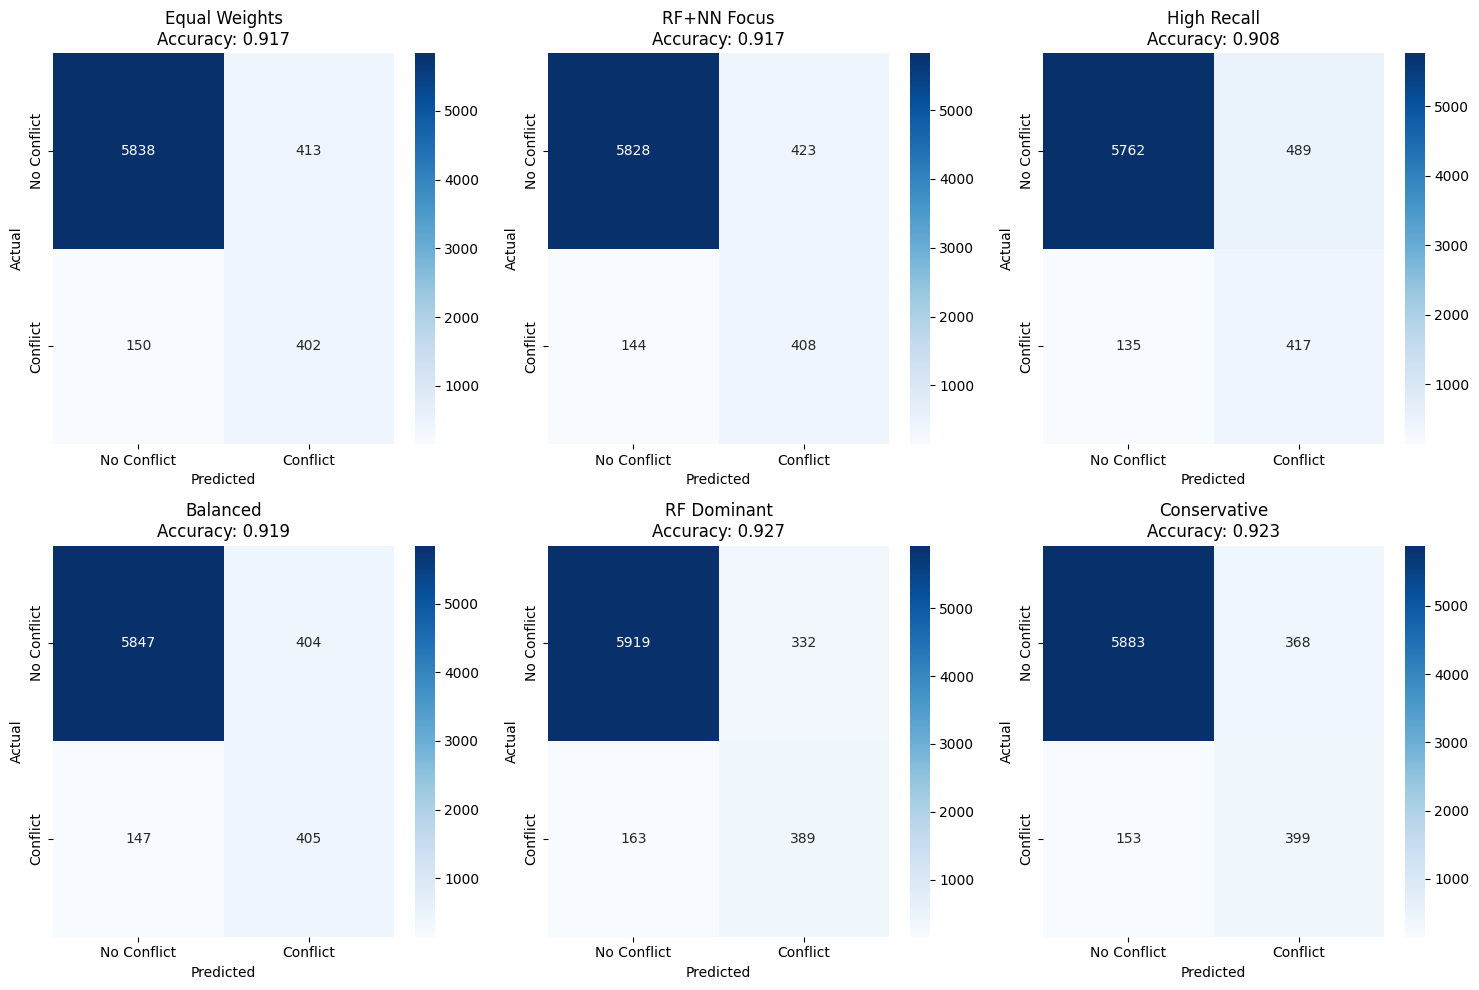

In [10]:
def create_weighted_ensembles(individual_results, min_recall=0.80):
    """Create simple weighted ensemble combinations"""
    
    # Get all model probabilities
    model_names = list(individual_results.keys())
    model_probs = {name: result['y_prob'] for name, result in individual_results.items()}
    
    ensembles = {}
    
    # Define different weight combinations
    weight_combinations = {
        'Equal Weights': {
            'Logistic Regression': 0.25, 'K-Nearest Neighbors': 0.25, 
            'Random Forest': 0.25, 'Neural Network': 0.25
        },
        'RF+NN Focus': {
            'Logistic Regression': 0.15, 'K-Nearest Neighbors': 0.15, 
            'Random Forest': 0.35, 'Neural Network': 0.35
        },
        'High Recall': {
            'Logistic Regression': 0.10, 'K-Nearest Neighbors': 0.10, 
            'Random Forest': 0.30, 'Neural Network': 0.50
        },
        'Balanced': {
            'Logistic Regression': 0.20, 'K-Nearest Neighbors': 0.15, 
            'Random Forest': 0.40, 'Neural Network': 0.25
        },
        'RF Dominant': {
            'Logistic Regression': 0.10, 'K-Nearest Neighbors': 0.20, 
            'Random Forest': 0.60, 'Neural Network': 0.10
        },
        'Conservative': {
            'Logistic Regression': 0.30, 'K-Nearest Neighbors': 0.25, 
            'Random Forest': 0.35, 'Neural Network': 0.10
        }
    }
    
    # Create ensembles for each weight combination
    for combo_name, weights in weight_combinations.items():
        # Calculate weighted probabilities
        weighted_probs = np.zeros(len(model_probs[model_names[0]]))
        for model_name, weight in weights.items():
            weighted_probs += weight * model_probs[model_name]
        
        # Make predictions
        weighted_pred = (weighted_probs > 0.5).astype(int)
        
        # Store results
        ensembles[combo_name] = {
            'y_pred': weighted_pred,
            'y_prob': weighted_probs,
            'weights': weights,
            'name': combo_name
        }
    
    return ensembles

# Replace the complex ensemble creation with this simple version
print("Creating weighted ensemble models...")
ensemble_results = create_weighted_ensembles(individual_results)

# Create comparison table for ensembles
ensemble_comparison = create_comparison_table(ensemble_results)
print("\n=== Weighted Ensemble Performance ===")
print(ensemble_comparison.sort_values('recall', ascending=False))

# Print weights for each ensemble
print("\n=== Ensemble Weights ===")
for name, result in ensemble_results.items():
    print(f"\n{name}:")
    for model, weight in result['weights'].items():
        print(f"  {model}: {weight:.2f}")

# Plot ensemble confusion matrices
plot_confusion_matrices(ensemble_results)


=== FINAL MODEL COMPARISON (Individual + Conservative Ensemble) ===
                       accuracy  precision  recall  f1_score  weighted_recall  \
model                                                                           
Random Forest            0.9291     0.5500  0.6975    0.6150           0.9291   
Conservative Ensemble    0.9234     0.5202  0.7228    0.6050           0.9234   
Neural Network           0.8853     0.3944  0.7717    0.5221           0.8853   
K-Nearest Neighbors      0.8911     0.3994  0.6793    0.5030           0.8911   
Logistic Regression      0.8524     0.3240  0.7536    0.4532           0.8524   

                       roc_auc  
model                           
Random Forest           0.9369  
Conservative Ensemble   0.9294  
Neural Network          0.9217  
K-Nearest Neighbors     0.8383  
Logistic Regression     0.8801  

Plotting final ROC curves...


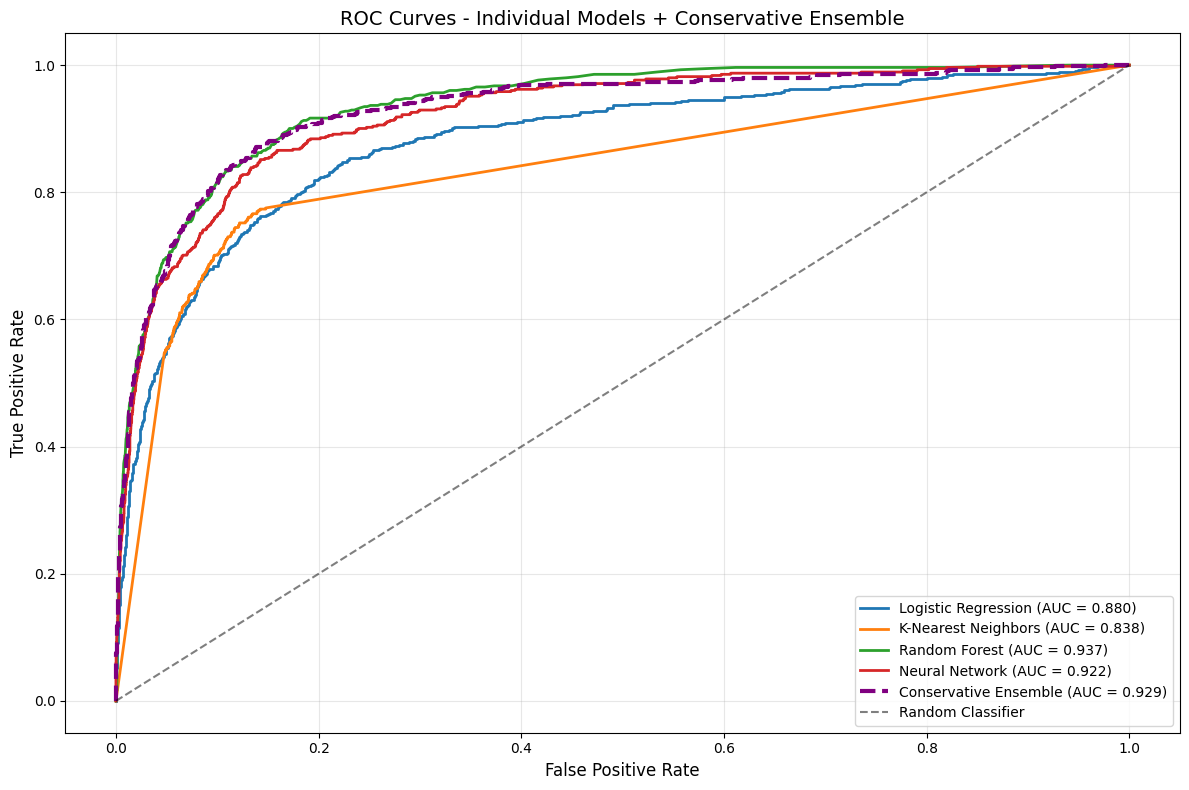

Plotting final Precision-Recall curves...


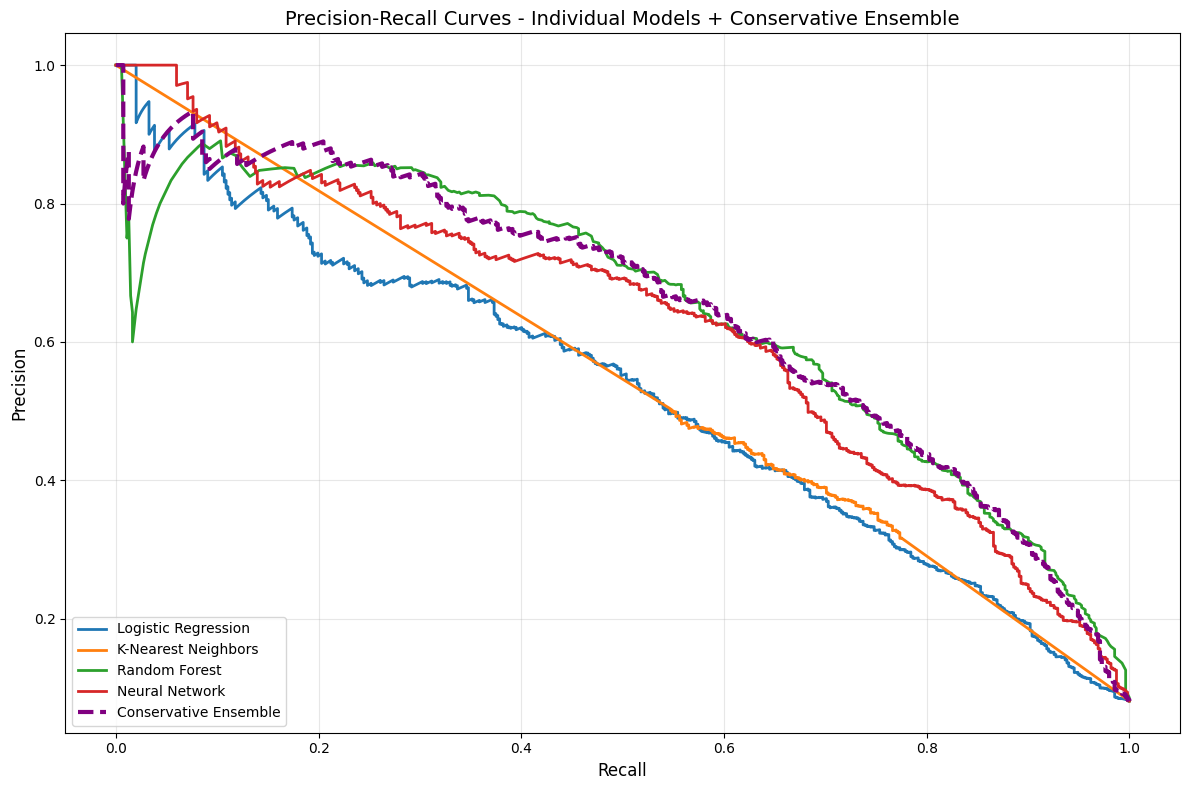


=== FINAL SUMMARY (SELECTED MODELS) ===
Models included: 4 Individual + 1 Conservative Ensemble

Best performers by metric:
• Best F1-Score: Random Forest (0.615)
• Best Recall: Neural Network (0.772)
• Best Precision: Random Forest (0.550)
• Best ROC AUC: Random Forest (0.937)

Conservative Ensemble Weights:
  • Logistic Regression: 0.30 (30%)
  • K-Nearest Neighbors: 0.25 (25%)
  • Random Forest: 0.35 (35%)
  • Neural Network: 0.10 (10%)

=== MODELS WITH ≥80% RECALL ===
No selected models achieved ≥80% recall

Closest to 80% recall:
                     recall  precision  f1_score
model                                           
Neural Network        0.772      0.394     0.522
Logistic Regression   0.754      0.324     0.453


In [11]:
# ROC Curves and Final Model Selection

def plot_final_roc_curves(individual_results, ensemble_results):
    """Plot ROC curves for individual models + Conservative ensemble only"""
    plt.figure(figsize=(12, 8))
    
    # Plot individual models
    individual_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Different colors for each
    for i, (name, result) in enumerate(individual_results.items()):
        fpr, tpr, _ = roc_curve(data_splits['y_test'], result['y_prob'])
        auc_score = roc_auc_score(data_splits['y_test'], result['y_prob'])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', 
                linewidth=2, color=individual_colors[i], linestyle='-')
    
    # Plot only Conservative ensemble
    if 'Conservative' in ensemble_results:
        result = ensemble_results['Conservative']
        fpr, tpr, _ = roc_curve(data_splits['y_test'], result['y_prob'])
        auc_score = roc_auc_score(data_splits['y_test'], result['y_prob'])
        plt.plot(fpr, tpr, label=f'Conservative Ensemble (AUC = {auc_score:.3f})', 
                linewidth=3, color='purple', linestyle='--')
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Individual Models + Conservative Ensemble', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_final_precision_recall_curves(individual_results, ensemble_results):
    """Plot Precision-Recall curves for individual models + Conservative ensemble only"""
    plt.figure(figsize=(12, 8))
    
    # Plot individual models
    individual_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i, (name, result) in enumerate(individual_results.items()):
        precision_vals, recall_vals, _ = precision_recall_curve(data_splits['y_test'], result['y_prob'])
        plt.plot(recall_vals, precision_vals, label=name, 
                linewidth=2, color=individual_colors[i], linestyle='-')
    
    # Plot only Conservative ensemble
    if 'Conservative' in ensemble_results:
        result = ensemble_results['Conservative']
        precision_vals, recall_vals, _ = precision_recall_curve(data_splits['y_test'], result['y_prob'])
        plt.plot(recall_vals, precision_vals, label='Conservative Ensemble', 
                linewidth=3, color='purple', linestyle='--')
    
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curves - Individual Models + Conservative Ensemble', fontsize=14)
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create final results with only individual models + Conservative ensemble
final_selected_results = {**individual_results}
if 'Conservative' in ensemble_results:
    final_selected_results['Conservative Ensemble'] = ensemble_results['Conservative']

# Create final comparison table
final_selected_comparison = create_comparison_table(final_selected_results)
print("\n=== FINAL MODEL COMPARISON (Individual + Conservative Ensemble) ===")
print(final_selected_comparison.sort_values('f1_score', ascending=False))

# Plot final ROC curves
print("\nPlotting final ROC curves...")
plot_final_roc_curves(individual_results, ensemble_results)

# Plot final Precision-Recall curves
print("Plotting final Precision-Recall curves...")
plot_final_precision_recall_curves(individual_results, ensemble_results)

# Final summary with selected models only
print("\n=== FINAL SUMMARY (SELECTED MODELS) ===")
print("Models included: 4 Individual + 1 Conservative Ensemble")
print("\nBest performers by metric:")
print(f"• Best F1-Score: {final_selected_comparison.sort_values('f1_score', ascending=False).index[0]} "
      f"({final_selected_comparison.sort_values('f1_score', ascending=False).iloc[0]['f1_score']:.3f})")
print(f"• Best Recall: {final_selected_comparison.sort_values('recall', ascending=False).index[0]} "
      f"({final_selected_comparison.sort_values('recall', ascending=False).iloc[0]['recall']:.3f})")
print(f"• Best Precision: {final_selected_comparison.sort_values('precision', ascending=False).index[0]} "
      f"({final_selected_comparison.sort_values('precision', ascending=False).iloc[0]['precision']:.3f})")
print(f"• Best ROC AUC: {final_selected_comparison.sort_values('roc_auc', ascending=False).index[0]} "
      f"({final_selected_comparison.sort_values('roc_auc', ascending=False).iloc[0]['roc_auc']:.3f})")

# Show Conservative ensemble weights
if 'Conservative' in ensemble_results:
    print(f"\nConservative Ensemble Weights:")
    for model, weight in ensemble_results['Conservative']['weights'].items():
        print(f"  • {model}: {weight:.2f} ({weight*100:.0f}%)")

# Models achieving at least 80% recall from selected models
print(f"\n=== MODELS WITH ≥80% RECALL ===")
high_recall_selected = final_selected_comparison[final_selected_comparison['recall'] >= 0.80]
if len(high_recall_selected) > 0:
    print(high_recall_selected.sort_values('precision', ascending=False)[['recall', 'precision', 'f1_score']].round(3))
else:
    print("No selected models achieved ≥80% recall")
    print("\nClosest to 80% recall:")
    closest_models = final_selected_comparison.sort_values('recall', ascending=False).head(2)
    print(closest_models[['recall', 'precision', 'f1_score']].round(3))

In [12]:
def generate_model_comparison_latex(individual_results, ensemble_results):
    """Generate LaTeX table comparing all models with specific metrics"""
    
    # Combine all results
    all_results = {**individual_results}
    if 'Conservative' in ensemble_results:
        all_results['Conservative Ensemble'] = ensemble_results['Conservative']
    
    # Initialize data storage
    models = list(all_results.keys())
    
    # Calculate detailed metrics for each model
    model_metrics = {}
    
    for model_name, result in all_results.items():
        y_true = data_splits['y_test']
        y_pred = result['y_pred']
        
        # Get classification report
        report = classification_report(y_true, y_pred, output_dict=True)
        
        model_metrics[model_name] = {
            'class_0_recall': report['0']['recall'],
            'class_1_recall': report['1']['recall'], 
            'weighted_recall': report['weighted avg']['recall'],
            'weighted_accuracy': accuracy_score(y_true, y_pred),
            'weighted_precision': report['weighted avg']['precision']
        }
    
    # Create LaTeX table
    print("$$")
    print("\\begin{array}{l" + "c" * len(models) + "}")
    
    # Header
    header = "\\text{Metric}"
    for model in models:
        # Shorten model names for table
        short_name = model.replace("Logistic Regression", "LR").replace("K-Nearest Neighbors", "KNN").replace("Random Forest", "RF").replace("Neural Network", "NN").replace("Conservative Ensemble", "Ensemble")
        header += f" & \\text{{{short_name}}}"
    header += " \\\\"
    print(header)
    print("\\hline")
    
    # Metrics rows
    metric_labels = {
        'class_0_recall': 'Class 0 Recall',
        'class_1_recall': 'Class 1 Recall', 
        'weighted_recall': 'Weighted Recall',
        'weighted_accuracy': 'Weighted Accuracy',
        'weighted_precision': 'Weighted Precision'
    }
    
    for metric_key, metric_label in metric_labels.items():
        row = f"\\text{{{metric_label}}}"
        for model in models:
            value = model_metrics[model][metric_key]
            row += f" & {value:.3f}"
        row += " \\\\"
        print(row)
    
    print("\\end{array}")
    print("$$")
    
    # Also print a readable summary
    print("\n=== MODEL COMPARISON SUMMARY ===")
    summary_df = pd.DataFrame(model_metrics).T
    summary_df.columns = ['Class 0 Recall', 'Class 1 Recall', 'Weighted Recall', 'Weighted Accuracy', 'Weighted Precision']
    print(summary_df.round(3))
    
    return summary_df

# Generate the comparison table
print("Generating model comparison LaTeX table...")
summary_table = generate_model_comparison_latex(individual_results, ensemble_results)

# Additional insights
print("\n=== KEY INSIGHTS ===")
print(f"Best Class 1 Recall: {summary_table['Class 1 Recall'].idxmax()} ({summary_table['Class 1 Recall'].max():.3f})")
print(f"Best Weighted Accuracy: {summary_table['Weighted Accuracy'].idxmax()} ({summary_table['Weighted Accuracy'].max():.3f})")
print(f"Best Weighted Precision: {summary_table['Weighted Precision'].idxmax()} ({summary_table['Weighted Precision'].max():.3f})")
print(f"Most Balanced Performance: {summary_table.mean(axis=1).idxmax()}")

Generating model comparison LaTeX table...
$$
\begin{array}{lccccc}
\text{Metric} & \text{LR} & \text{KNN} & \text{RF} & \text{NN} & \text{Ensemble} \\
\hline
\text{Class 0 Recall} & 0.861 & 0.910 & 0.950 & 0.895 & 0.941 \\
\text{Class 1 Recall} & 0.754 & 0.679 & 0.697 & 0.772 & 0.723 \\
\text{Weighted Recall} & 0.852 & 0.891 & 0.929 & 0.885 & 0.923 \\
\text{Weighted Accuracy} & 0.852 & 0.891 & 0.929 & 0.885 & 0.923 \\
\text{Weighted Precision} & 0.923 & 0.924 & 0.938 & 0.931 & 0.938 \\
\end{array}
$$

=== MODEL COMPARISON SUMMARY ===
                       Class 0 Recall  Class 1 Recall  Weighted Recall  \
Logistic Regression             0.861           0.754            0.852   
K-Nearest Neighbors             0.910           0.679            0.891   
Random Forest                   0.950           0.697            0.929   
Neural Network                  0.895           0.772            0.885   
Conservative Ensemble           0.941           0.723            0.923   

              